In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
from torch.distributions import Normal, Uniform

import sys
sys.path.append('../drnpe')

import lightning

from hydra import compose, initialize
from hydra.utils import instantiate

import matplotlib.pyplot as plt

We load the config and instantiate the data module:

In [2]:
with initialize(version_base=None, config_path="../drnpe/conf"):
    cfg = compose(config_name="config")

lightning.seed_everything(cfg.seed)

datamodule = instantiate(cfg.datamodule)

Seed set to 42


We also load in two encoders, one trained with the standard NPE objective (i.e., very large $\lambda$ in primal DRNPE) and one trained with the DRNPE objective with a small $\lambda$:

In [3]:
encoder_npe = instantiate(cfg.encoder)

state_dict = torch.load("../trained_ckpts/network_primal_npe.ckpt")['state_dict']
encoder_npe.load_state_dict(state_dict)
encoder_npe.eval()

Encoder(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

In [4]:
encoder_drnpe = instantiate(cfg.encoder)

state_dict = torch.load("../trained_ckpts/network_primal_drnpe.ckpt")['state_dict']
encoder_drnpe.load_state_dict(state_dict)
encoder_drnpe.eval()

Encoder(
  (net): LocationScaleNet(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

We define a function to plot the nominal versus empirical coverage probabilities of credible intervals computed using a trained `encoder`. This function generates a new batch of `num_test_samples` $(z,x)$ pairs. If `likelihood_stdev_multiplier = 1.0`, these pairs are generated from the same generative model used during training. If this multiplier does not equal 1.0, the model used for evaluation is misspecified.

In [5]:
def plot_coverage_probabilities(num_test_samples, encoder, dist, misspec_param):
    num_subplots = len(misspec_param)
    fig, ax = plt.subplots(1, num_subplots, figsize = (4 * num_subplots, 4))
    if num_subplots == 1:
        ax = [ax]
    
    for j in range(num_subplots):
        if dist == "normal":
            z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples])
            x = Normal(z, misspec_param[j] * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1,0)
        elif dist == "uniform":
            z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples])
            x = Uniform(z - misspec_param[j], z + misspec_param[j]).sample([datamodule.num_observations]).permute(1,0)
        
        mu, logsigma = encoder.net(x)
        sigma = torch.exp(logsigma)

        confidence_levels = torch.linspace(0.05, 0.95, steps = 19)
        quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2)

        lower = (mu.unsqueeze(-1) - quantiles * sigma.unsqueeze(-1)).detach().cpu()
        upper = (mu.unsqueeze(-1) + quantiles * sigma.unsqueeze(-1)).detach().cpu()

        coverage_probs = ((z.cpu().unsqueeze(-1) >= lower) * (z.cpu().unsqueeze(-1) <= upper)).float().mean(0)
        
        _ = ax[j].scatter(confidence_levels.cpu(), coverage_probs.cpu())
        _ = ax[j].axline((0,0), slope = 1, color = 'black')
        _ = ax[j].set_xlim(0, 1)
        _ = ax[j].set_ylim(0, 1)
        _ = ax[j].set_title(f'misspecification param = {misspec_param[j]}')
        _ = ax[j].set_xlabel('Nominal coverage probability')
        _ = ax[j].set_ylabel('Empirical coverage probability')
    
    _ = fig.tight_layout()

**Scenario 1A:** Train with standard NPE objective, evaluate on correctly specified model:

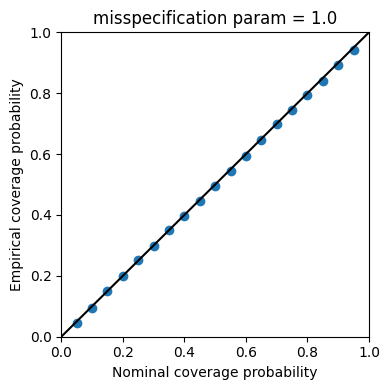

In [6]:
plot_coverage_probabilities(10000, encoder_npe, "normal", [1.0])

**Scenario 1B:** Train with standard NPE objective, evaluate on misspecified model with Gaussian likelihood:

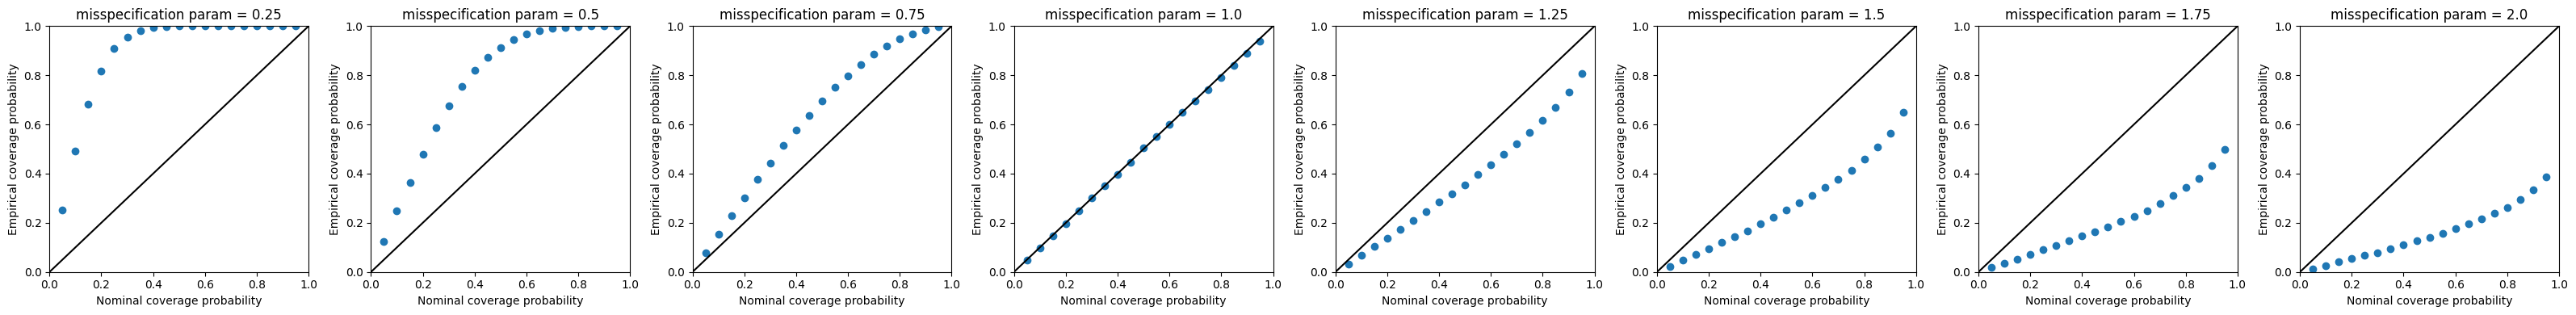

In [7]:
plot_coverage_probabilities(10000, encoder_npe, "normal", [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

**Scenario 1C:** Train with standard NPE objective, evaluate on misspecified model with Uniform likelihood:

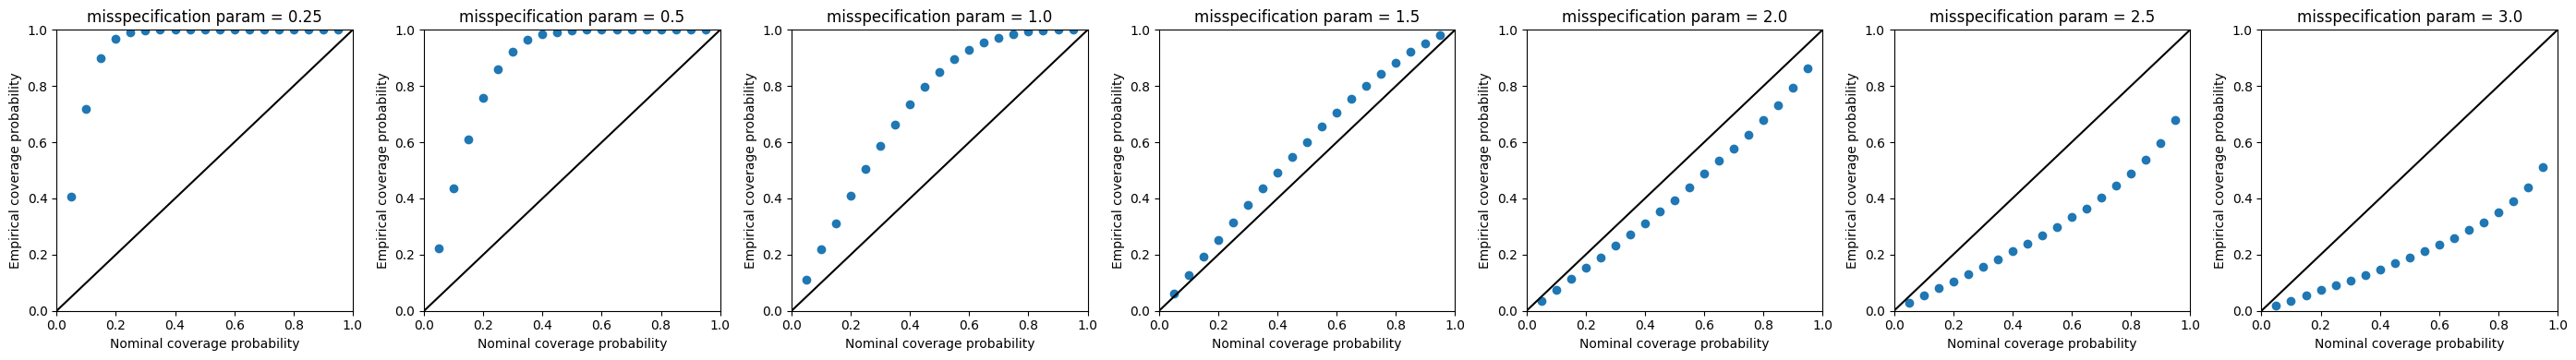

In [8]:
plot_coverage_probabilities(10000, encoder_npe, "uniform", [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

**Scenario 2A:** Train with DRNPE objective, evaluate on correctly specified model:

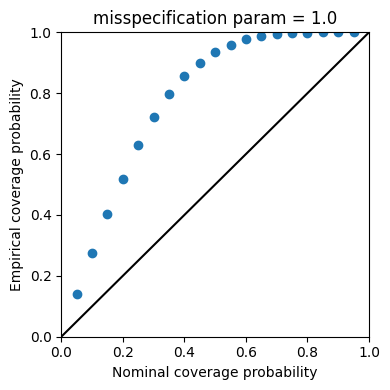

In [9]:
plot_coverage_probabilities(10000, encoder_drnpe, "normal", [1.0])

**Scenario 2B:** Train with DRNPE objective, evaluate on misspecified model with Gaussian likelihood:

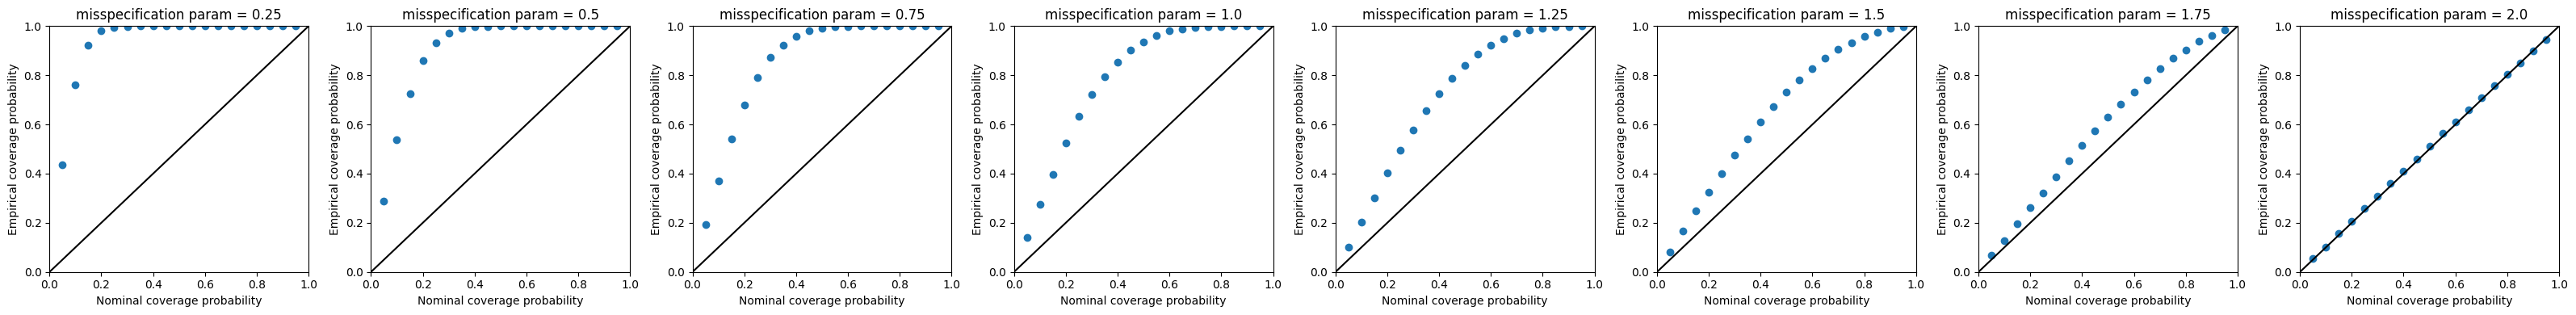

In [10]:
plot_coverage_probabilities(10000, encoder_drnpe, "normal", [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])

**Scenario 2C:** Train with DRNPE objective, evaluate on misspecified model with Uniform likelihood:

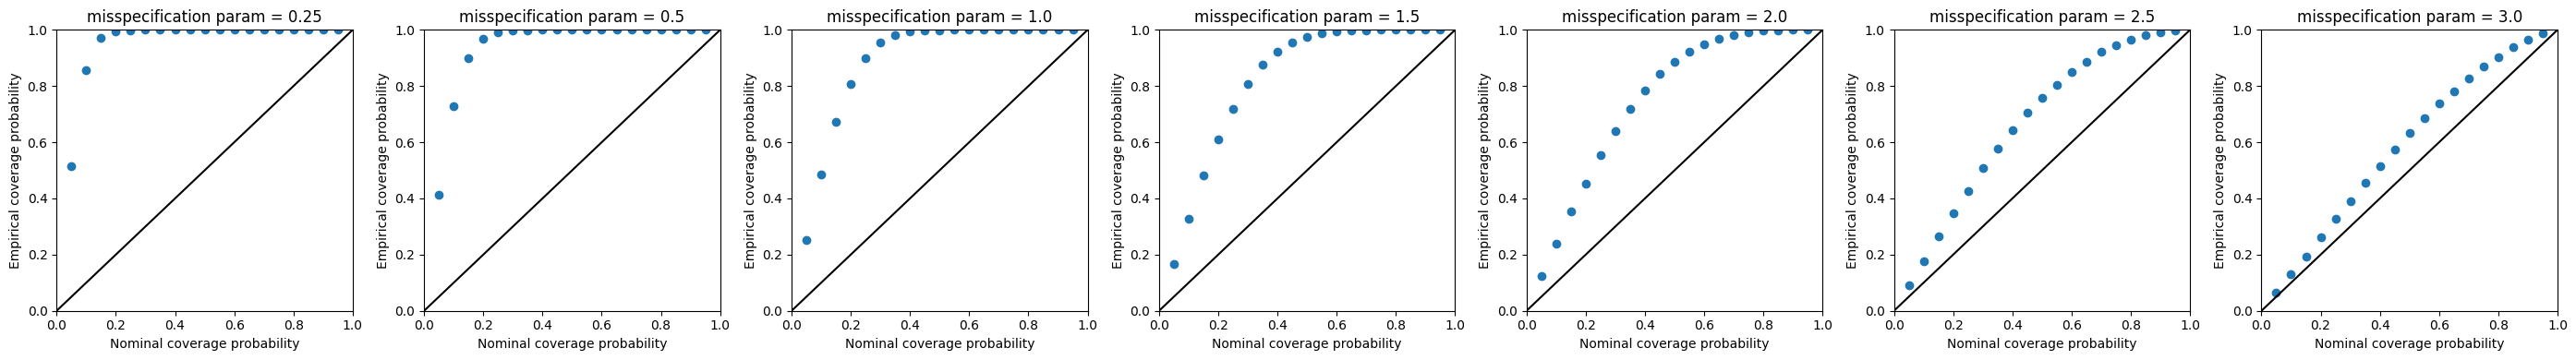

In [11]:
plot_coverage_probabilities(10000, encoder_drnpe, "uniform", [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])